#### import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from ydata_profiling import ProfileReport
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#### Read Data and Understand it

In [2]:
ratings=pd.read_csv(r"D:\ali\SIC\Project\Recoomend System\movies_metadata.csv\ratings_small.csv")
movies=pd.read_csv(r"D:\ali\SIC\Project\Recoomend System\movies_metadata.csv\movies_metadata.csv")
links=pd.read_csv(r"D:\ali\SIC\Project\Recoomend System\movies_metadata.csv\links_small.csv")

C:\Users\DELL\AppData\Local\Temp\ipykernel_24948\416021315.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies=pd.read_csv(r"D:\ali\SIC\Project\Recoomend System\movies_metadata.csv\movies_metadata.csv")


In [3]:
movies.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

#### inspection and cleanning

In [4]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [5]:
movies = movies[movies['id'].str.isnumeric()]
movies['id'] = movies['id'].astype(int)
movies['budget']=movies['budget'].astype(int)
movies['popularity']=movies['popularity'].astype(float)
movies['revenue']=movies['revenue'].astype(float)

In [6]:
movies.drop(['belongs_to_collection','homepage','spoken_languages','original_title','poster_path',],inplace=True,axis=1)

In [7]:
movies.drop_duplicates(inplace=True,keep='first')

In [8]:
movies['tagline']=movies['tagline'].fillna('')
movies['overview']=movies['overview'].fillna('')

In [9]:
movies.isnull().sum()
movies.dropna(inplace=True)

In [10]:
def extract_names(field_str):
    try:
        items_list = ast.literal_eval(field_str)
        return " ".join([item['name'] for item in items_list])
    except:
        return ""

movies['production_countries'] = movies['production_countries'].apply(extract_names)
movies['production_companies'] = movies['production_companies'].apply(extract_names)
movies['genres'] = movies['genres'].apply(extract_names)

In [11]:
data_model=movies[['id','imdb_id','genres','original_language','overview','title','production_countries','production_companies','runtime','tagline']].copy()
data_model = data_model.reset_index(drop=True)
data_model.to_csv(r"D:\ali\SIC\Project\Recoomend System\movies_metadata.csv\data_model.csv",index=False)
data_model.isnull().sum()

id                      0
imdb_id                 0
genres                  0
original_language       0
overview                0
title                   0
production_countries    0
production_companies    0
runtime                 0
tagline                 0
dtype: int64

In [12]:
movies['runtime'] = movies['runtime'].replace(0, np.nan)
movies['budget'] = movies['budget'].replace(0, np.nan)
movies['revenue'] = movies['revenue'].replace(0, np.nan)
movies['runtime'] = movies['runtime'].fillna(movies['runtime'].median())
movies['budget'] = movies['budget'].fillna(movies['budget'].mean())
movies['revenue'] = movies['revenue'].fillna(movies['revenue'].mean())

In [13]:
movies.sample()

,adult,budget,genres,id,imdb_id,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,status,tagline,title,video,vote_average,vote_count
44475,False,250000.0,Adventure Action Fantasy Horror Science Fictio...,16266,tt1132130,en,"On December 21, 2012 four strangers on a journ...",2.37802,,,2008-02-12,6.888892e+07,85.0,Released,An Ancient Prophecy Foretold. A Scientific Dis...,2012 Doomsday,False,2.3,32.0


In [14]:
movies=movies[movies['genres']!='']
movies=movies[movies['overview']!='']
movies=movies[movies['production_companies']!='']
movies=movies[movies['production_countries']!='']
movies=movies[movies['tagline']!='']

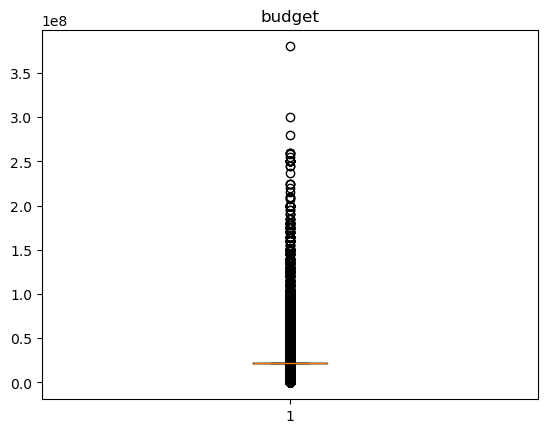

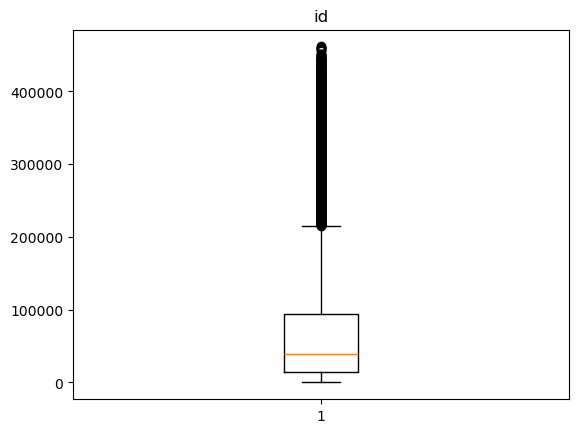

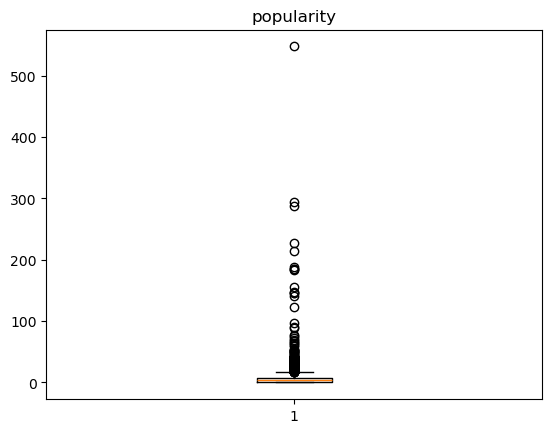

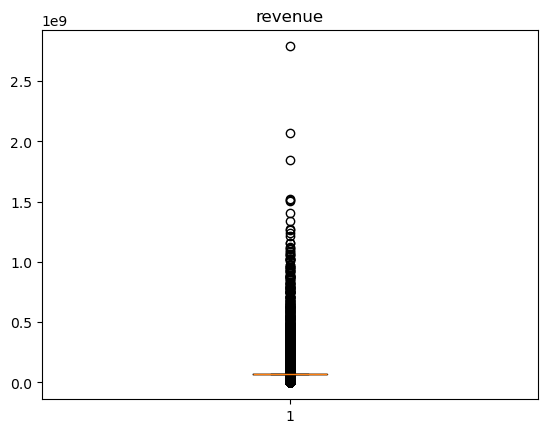

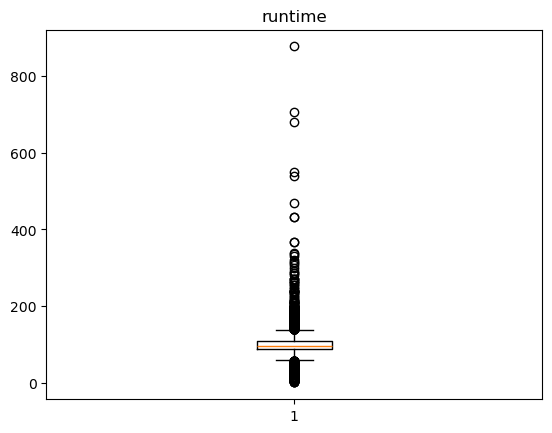

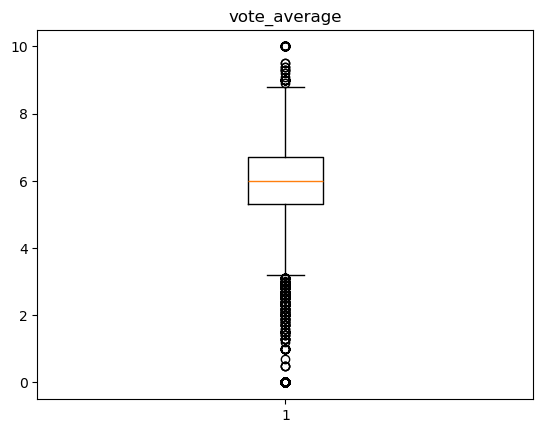

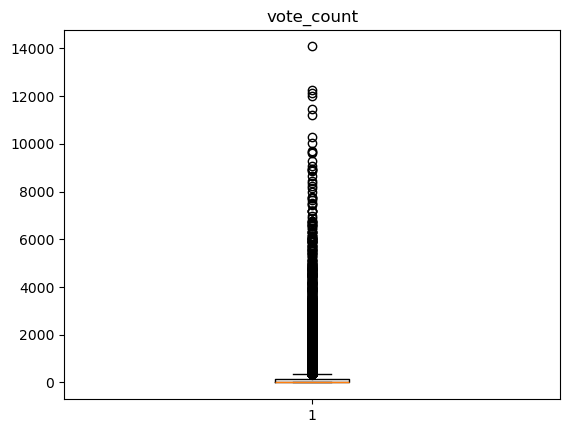

In [15]:
numeric_cols = movies.select_dtypes(include=['float64', 'int64']).columns

for i in numeric_cols:
    plt.figure()
    plt.boxplot(movies[i].dropna())
    plt.title(i)
    plt.show()

In [16]:
outlier=['popularity','vote_count','vote_average']
for i in outlier:
    q1=movies[i].quantile(.25)
    q3=movies[i].quantile(.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    movies=movies[(movies[i]>=lower)&(movies[i]<=upper)]

#### EDA & Visualization

In [ ]:
movies.describe()

- **Outliers & Boxplots**

In [ ]:

movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce')
movies['revenue'] = pd.to_numeric(movies['revenue'], errors='coerce')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=movies['budget'], color='skyblue')
plt.title('Outliers in Budget')

plt.subplot(1, 2, 2)
sns.boxplot(y=movies['revenue'], color='salmon')
plt.title('Outliers in Revenue')

plt.tight_layout()
plt.show()

- **Heatmap**

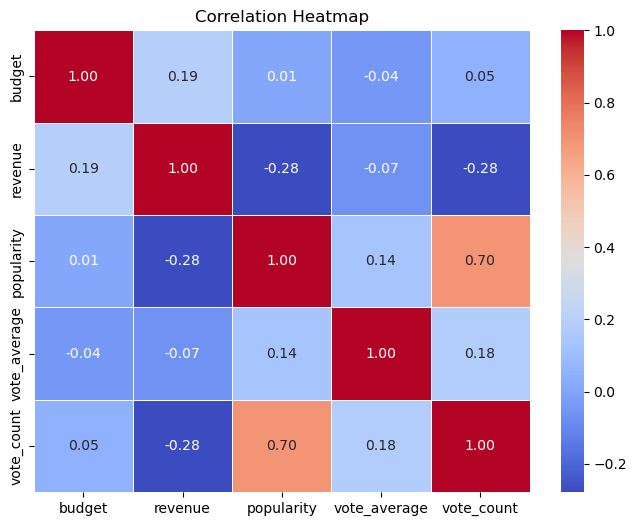

In [30]:

num_cols = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']
num_movies = movies[num_cols].apply(pd.to_numeric, errors='coerce')
plt.figure(figsize=(8, 6))
sns.heatmap(num_movies.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

- **Missing values**

In [ ]:
print(movies.isna().sum())


plt.figure(figsize=(12, 6))

sns.heatmap(movies.isna(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Seaborn)', fontsize=14)
plt.xlabel('Columns')
plt.show()

- **Display duration**

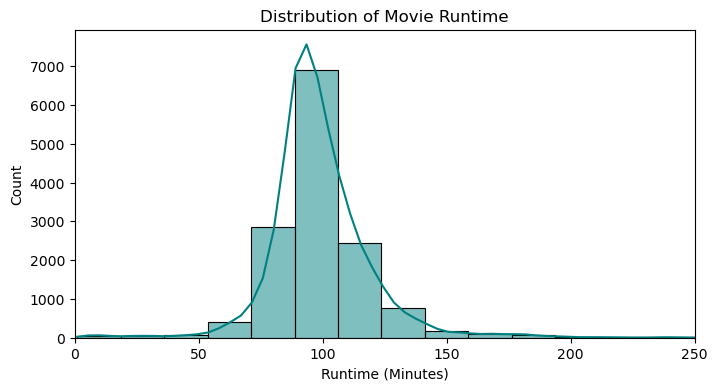

In [31]:
movies['runtime'] = pd.to_numeric(movies['runtime'], errors='coerce')

plt.figure(figsize=(8, 4))
sns.histplot(movies['runtime'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of Movie Runtime')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Count')
plt.xlim(0, 250)
plt.show()



- **Rating & Vote Distribution**

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(movies['vote_average'], bins=20, kde=True, color='skyblue')
plt.title('vote average')
plt.xlabel('rating')
plt.ylabel('count')

plt.subplot(1, 2, 2)
sns.histplot(movies['vote_count'], bins=20, kde=True, color='green')
plt.title('vote count')
plt.xlabel('rating')
plt.ylabel('count')

plt.tight_layout()
plt.show()



- **films types**

In [ ]:
from collections import Counter


all_genres = " ".join(movies['genres'].dropna()).split()

genre_counts = Counter(all_genres)


genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(data=genre_df, x='Count', y='Genre', hue='Genre', legend=False, palette='magma')
plt.title('Top Genres')
plt.xlabel('count')
plt.ylabel('Genres')
plt.show()

- **top 10 films**

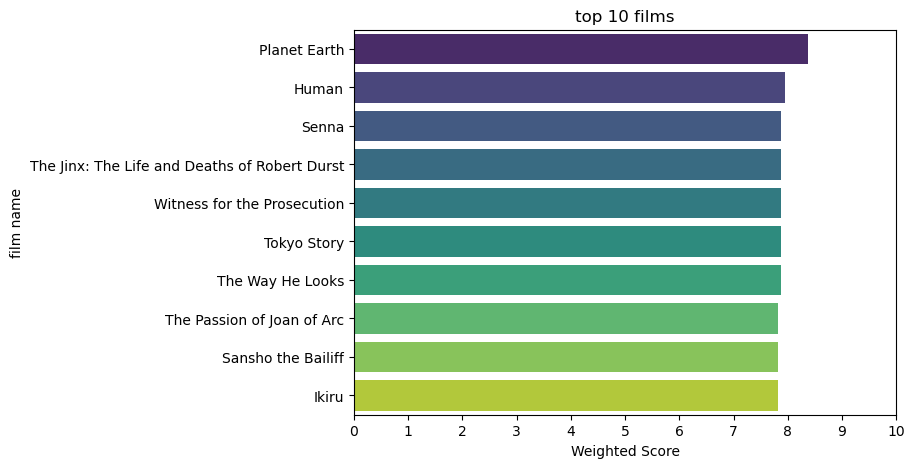

In [32]:

C = movies['vote_average'].mean() # average rating films (c)


m = movies['vote_count'].quantile(0.60) # movies with a rating 0.60 or more

q_movies = movies.copy().loc[movies['vote_count'] >= m] #Filter movies under review


def weighted_rating(x, m=m, C=C): # calculate the weighted_rating of film
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m) * R) + (m / (m + v) * C)


q_movies['score'] = q_movies.apply(weighted_rating, axis=1)  #Storing outputs weighted_rating


top_10 = q_movies.sort_values('score', ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(data=top_10, x='score', y='title', hue='title', legend=False, palette='viridis')
plt.title('top 10 films')
plt.xlabel('Weighted Score')
plt.ylabel('film name')

plt.xticks(range(0, 11))
plt.show()

- **top 10 language**

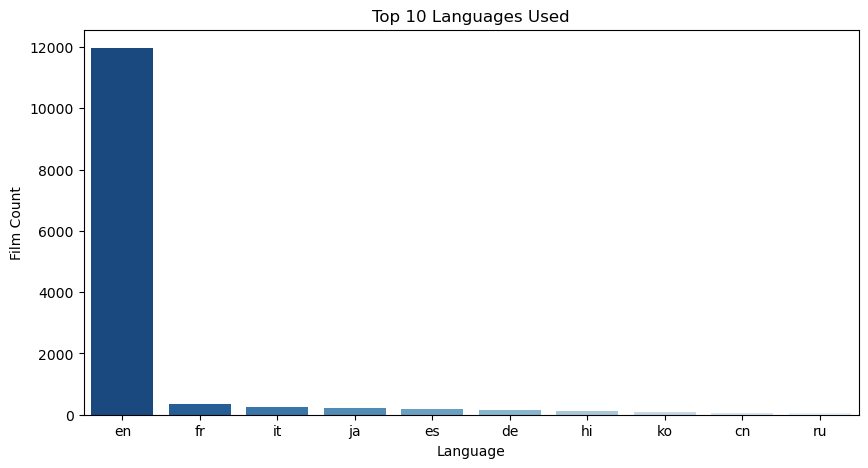

In [33]:
top_languages = movies['original_language'].value_counts().head(10) # top 10 language used

plt.figure(figsize=(10, 5))

sns.barplot(x=top_languages.index, y=top_languages.values, hue=top_languages.index, palette='Blues_r', legend=False)

plt.title('Top 10 Languages Used')
plt.xlabel('Language')
plt.ylabel('Film Count')
plt.show()

- **User Opinions**

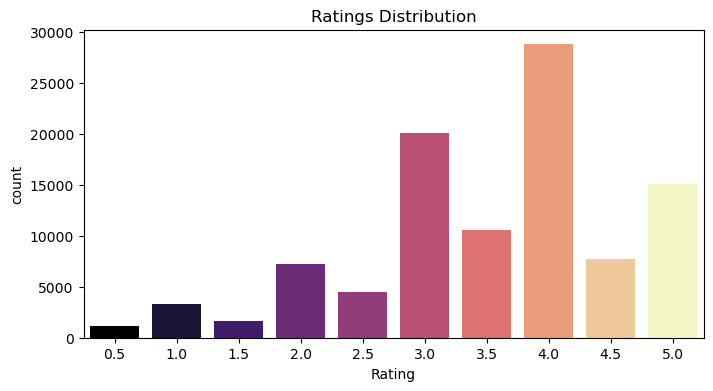

In [34]:
plt.figure(figsize=(8, 4))
sns.countplot(data=ratings, x='rating', hue='rating', legend=False, palette='magma')
plt.title('Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('count')
plt.show()





- **Top Production Companies**

# Model Trainnig

#### prepare data for trainnig

In [17]:
data_model

,id,imdb_id,genres,original_language,overview,title,production_countries,production_companies,runtime,tagline
0,862,tt0114709,Animation Comedy Family,en,"Led by Woody, Andy's toys live happily in his ...",Toy Story,United States of America,Pixar Animation Studios,81.0,
1,8844,tt0113497,Adventure Fantasy Family,en,When siblings Judy and Peter discover an encha...,Jumanji,United States of America,TriStar Pictures Teitler Film Interscope Commu...,104.0,Roll the dice and unleash the excitement!
2,15602,tt0113228,Romance Comedy,en,A family wedding reignites the ancient feud be...,Grumpier Old Men,United States of America,Warner Bros. Lancaster Gate,101.0,Still Yelling. Still Fighting. Still Ready for...
3,31357,tt0114885,Comedy Drama Romance,en,"Cheated on, mistreated and stepped on, the wom...",Waiting to Exhale,United States of America,Twentieth Century Fox Film Corporation,127.0,Friends are the people who let you be yourself...
4,11862,tt0113041,Comedy,en,Just when George Banks has recovered from his ...,Father of the Bride Part II,United States of America,Sandollar Productions Touchstone Pictures,106.0,Just When His World Is Back To Normal... He's ...
...,...,...,...,...,...,...,...,...,...,...
45009,30840,tt0102797,Drama Action Romance,en,"Yet another version of the classic epic, with ...",Robin Hood,Canada Germany United Kingdom United States of...,Westdeutscher Rundfunk (WDR) Working Title Fil...,104.0,
45010,111109,tt2028550,Drama,tl,An artist struggles to finish his work while a...,Century of Birthing,Philippines,Sine Olivia,360.0,
45011,67758,tt0303758,Action Drama Thriller,en,"When one of her hits goes wrong, a professiona...",Betrayal,United States of America,American World Pictures,90.0,A deadly game of wits.
45012,227506,tt0008536,,en,"In a small town live two brothers, one a minis...",Satan Triumphant,Russia,Yermoliev,87.0,


In [18]:
data_model['content']=data_model['content'] = (
    data_model['title']+ ' ' +
    data_model['overview']+ ' ' +
    data_model['genres']+ ' ' +
    data_model['tagline']
)

#### train the model

In [19]:
cv_test = CountVectorizer(stop_words='english')  # من غير max_features
cv_test.fit(data_model['content'].values.astype('U'))
print(f"num of unique words: {len(cv_test.vocabulary_)}")

num of unique words: 81789


In [20]:
cv=CountVectorizer(max_features=40000,stop_words='english')

In [21]:
vector=cv.fit_transform(data_model['content'].values)

In [22]:
vector.shape

(45014, 40000)

In [23]:
def recommend(movie_title, top_n=5):
    matches = data_model[data_model['title'] == movie_title]
    if matches.empty:
        return []
    index = matches.index[0] 
    sim_scores = cosine_similarity(vector[index], vector).flatten()
    distance = sorted(list(enumerate(sim_scores)), reverse=True, key=lambda x: x[1])
    return [data_model.iloc[i[0]]['title'] for i in distance[1:top_n+1]]

In [24]:
recommend('Toy Story',6)

['Toy Story 3',
 'Toy Story 2',
 "Andy Hardy's Blonde Trouble",
 'The 40 Year Old Virgin',
 'Andy Kaufman Plays Carnegie Hall',
 'Andy Peters: Exclamation Mark Question Point']

#### ُevaluation


In [25]:
ratings_links = ratings.merge(
    links[['movieId', 'tmdbId']],
    on='movieId',
    how='inner'
)
ratings_model = ratings_links.merge(
    data_model[['id', 'title']],
    left_on='tmdbId',
    right_on='id',
    how='inner'
)

In [26]:
liked_movies = ratings_model[ratings_model['rating'] >= 4]

In [27]:
import random

def precision_at_k_user(user_id, k=5):
    user_liked_list = liked_movies[liked_movies['userId'] == user_id]['title'].tolist()
    
    if len(user_liked_list) < 2:
        return None
    
    input_movie = user_liked_list[0]
    target_movies = set(user_liked_list[1:])
    
    recommendations = recommend(input_movie, k)
    if len(recommendations) == 0:
        return 0
    
    relevant = sum(movie in target_movies for movie in recommendations)
    return relevant / len(recommendations)

all_users = liked_movies['userId'].unique()
sample_users = random.sample(list(all_users), min(200, len(all_users)))

scores = []
for uid in sample_users:
    score = precision_at_k_user(uid, k=5)
    if score is not None:
        scores.append(score)

print(f"متوسط Precision@5: {sum(scores)/len(scores):.2%}")
print(f"عدد المستخدمين اللي اتقيّموا: {len(scores)}")

متوسط Precision@5: 4.65%
عدد المستخدمين اللي اتقيّموا: 198


In [28]:
def random_precision_at_k(user_id, k=5):
    user_liked_list = liked_movies[liked_movies['userId'] == user_id]['title'].tolist()
    
    if len(user_liked_list) < 2:
        return None
    
    target_movies = set(user_liked_list[1:])
    random_recs = random.sample(list(data_model['title']), k)
    
    relevant = sum(movie in target_movies for movie in random_recs)
    return relevant / k

random_scores = []
for uid in sample_users:
    score = random_precision_at_k(uid, k=5)
    if score is not None:
        random_scores.append(score)

print(f"Random Baseline Precision@5: {sum(random_scores)/len(random_scores):.2%}")

Random Baseline Precision@5: 0.00%


In [29]:
data_model['title'].nunique()

41871